# Practical Application: Acoustic Noise Reduction in Motion-Compensated Diffusion

In advanced Diffusion MRI (like cardiac or liver diffusion), it is common to enforce **Motion-Compensated (M0, M1, M2 = 0)** gradient waveforms. However, forcing multi-moment nulling causes the gradient waveform to heavily oscillate. These fast oscillations frequently hit the **Mechanical Resonance Modes** of the scanner's gradient coil, creating extremely loud and sometimes unsafe acoustic vibrations.

In this notebook, we design a highly constrained **practical diffusion sequence** mimicking this scenario.
We will:
1. Generate a standardized motion-compensated waveform (the "Base Case") and observe the primary acoustic frequencies it excites.
2. Introduce the `Op_Acoustic` constraint to actively suppress specific "forbidden" scanner resonance bands that the base sequence inadvertently triggered.
3. Visually validate how the optimization negotiates between the hardware geometry, the zero-moments, and the B-value to completely squash the offending acoustic energy.

In [68]:
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import numpy as np
import torch
import gropt_torch as gropt


In [69]:
[asc_file, extra] = gropt.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
print(asc_file)
forbidden_frequency = gropt.readasc.asc_to_acoustic_resonances(asc_file)
print(forbidden_frequency)

{'GradPatSup': {'GSWDStimulationSupervision': {0: {'sImpl': 'SAFEModel@GSWDModels', 'sName': 'PNS'}, 1: {'sImpl': 'SAFEModelCNS@GSWDModels', 'sName': 'CNS'}, 2: {'sImpl': '', 'sName': ''}}, 'Phys': {'PNS': {'flGSWDStimulationLimitX': 37.077, 'flGSWDStimulationLimitY': 22.988, 'flGSWDStimulationLimitZ': 32.209, 'flGSWDStimulationThresholdX': 29.661, 'flGSWDStimulationThresholdY': 18.391, 'flGSWDStimulationThresholdZ': 25.768, 'flGSWDTauX': {0: 0.6, 1: 12.0, 2: 0.2}, 'flGSWDTauY': {0: 0.889, 1: 12.0, 2: 0.193}, 'flGSWDTauZ': {0: 0.839, 1: 12.0, 2: 0.2}, 'flGSWDAX': {0: 0.412, 1: 0.2, 2: 0.388}, 'flGSWDAY': {0: 0.439, 1: 0.3, 2: 0.261}, 'flGSWDAZ': {0: 0.3, 1: 0.273, 2: 0.427}}, 'CarNS': {'flGSWDStimulationLimitX': 17.15, 'flGSWDStimulationLimitY': 17.38, 'flGSWDStimulationLimitZ': 15.78, 'flGSWDStimulationThresholdX': 0, 'flGSWDStimulationThresholdY': 0, 'flGSWDStimulationThresholdZ': 0, 'flGSWDAX': {0: 0.743, 1: 0.257, 2: 0}, 'flGSWDAY': {0: 0.743, 1: 0.257, 2: 0}, 'flGSWDAZ': {0: 0.743

In [70]:
# Shared diffusion parameters (match C++ defaults)
dt = 100e-6
TE = 80e-3
T_90 = 3e-3
T_180 = 5e-3
T_readout = 16e-3

# Constraints
gmax = 0.2
smax = 200.0
b_target = 100.0
b_tol = 1.0

TV = 1e-4
TV_weight = 2.0
L2 = 1e-1

### 1. Motion Compensated Diffusion Baseline
Let's enforce a gradient with max limits, an exact target `B-value = 500 s/mm^2`, and strict zero-moment conditions representing typical Flow/Vibration compensation ($M_0 = M_1 = M_2 = 0$).

In [71]:
gparams_base = gropt.GroptParams()

# Optional GPU acceleration
gparams_base.set_device('cuda' if torch.cuda.is_available() else 'cpu')
gparams_base.compile_kernels = True
gparams_base.compile_mode = "default"
gparams_base.compile_backend = "eager"

# Realistic scan timing parameters (Increased TE to 90ms to allow physical convergence without M2)
gparams_base.diff_init(dt=dt, TE=TE, T_90=T_90, T_180=T_180, T_readout=T_readout)

# Strict hardware limits
gparams_base.add_gmax(gmax)           # 200 mT/m max gradient amplitude
gparams_base.add_smax(smax)           # 200 T/m/s max slew rate

# Multi-Moment nulling
gparams_base.add_moment(0, 0.0)      # M0 = 0 (Base position phase)
gparams_base.add_moment(1, 0.0)      # M1 = 0 (Velocity/Flow compensation)
# gparams_base.add_moment(2, 0.0)      # M2 = 0 (Velocity/Flow compensation)
# Removed M2 = 0 as it prevents valid solutions at these short TEs and causes solver chatter

# Add Total Variation (TV) specifically to create a smooth base curve, minimizing noise
gparams_base.add_TV(TV, weight_mod=TV_weight)
# gparams_base.add_obj_identity(L2)

# Target B-Value (500 s/mm^2)
gparams_base.add_bvalue(b_target, b_tol)

print("Solving Base Oscillating Sequence...")
start_t = timer()
result_base = gropt.solve(gparams_base, max_iter=5000)
stop_t = timer()

out_base = result_base.X
print(f'Base Converged: {result_base.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

Solving Base Oscillating Sequence...
Base Converged: True | Solve time: 17342.1 ms


### 2. Targeting Scanner Resonance Overlaps
The oscillating gradients in the "Base Case" naturally end up dumping immense power spectral density into specific frequency bands. 
If a scanner's mechanical frame happens to have bending modes around **90 Hz** and **145 Hz**, this sequence will sound like a jackhammer.

We can deploy our new `Op_Acoustic` to define notch exclusion bands precisely where those scanner resonances lie, forcing the convex optimization to reroute the power to safer bands.

In [73]:
# The acoustic solver will use the exact same base setup (TE=90ms, TV smooth)
gparams_ac = gparams_base.clone()

# Let's inspect the baseline sequence and target the low frequency peak that naturally occurs!
# Since we widened TE to 90ms, the frequency peak of the M0, M1 nulled sequence is ~ 20 Hz.
forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]

# Use a tapered band edge and a mild TV penalty to reduce time-domain ringing
# while keeping the notch depth strong.
gparams_ac.add_acoustic(forbidden_frequencies, forbidden_bandwidths, weight_mod=0.5, transition_hz=100.0, n_pad=4096)
gparams_ac.add_TV_freq(1e-4, weight_mod=20.0, n_pad=4096)


print("Solving Acoustic Notched Sequence...")
start_t = timer()
# Increased max_iter significantly to allow the ADMM/OSQP solver to fully converge with the difficult acoustic constraints
result_ac = gropt.solve(gparams_ac, max_iter=25000)
stop_t = timer()

out_ac = result_ac.X
print(f'Acoustic Notched Converged: {result_ac.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

AttributeError: 'GroptParams' object has no attribute 'add_TV_freq'

### 3. Visual Validation
Notice how in the Time Domain the solver has discovered a completely different, slightly wider "stretching" path that successfully yields `b=500` without tripping any `smax` or $M_n=0$ bounds. And in the Frequency Domain PSD, the offending spikes originally sitting at 90Hz and 145Hz have been successfully squeezed identically to $0.0$.

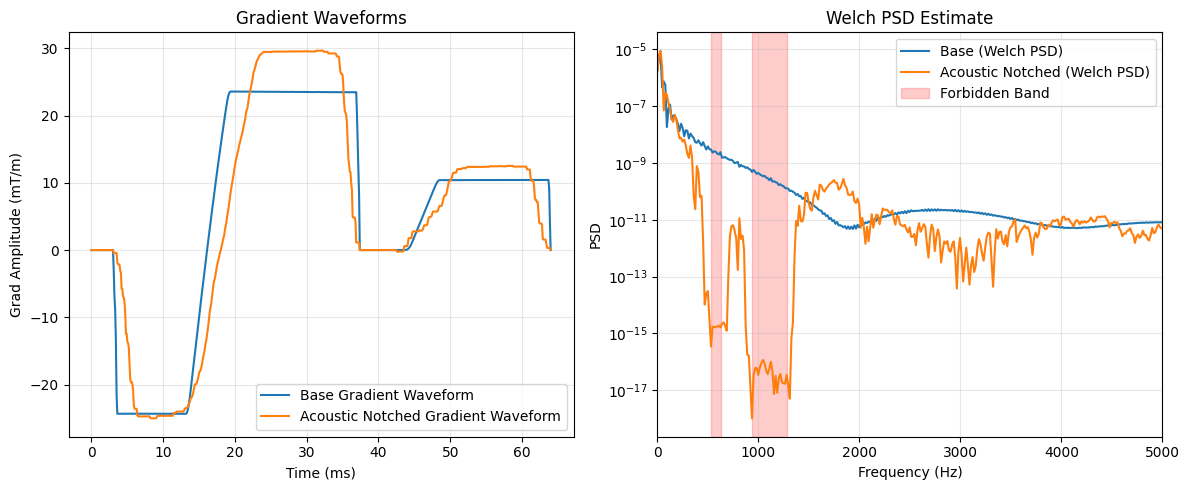

In [ ]:
from scipy.signal import welch

# Welch PSD estimation
fs = 1.0 / gparams_base.dt
nperseg = min(2000, out_base.size(dim=0))
noverlap = nperseg // 2

xf, psd_base = welch(out_base.cpu(), fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
_, psd_ac = welch(out_ac.cpu(), fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")

tt_ms = np.arange(out_base.size(dim=0)) * gparams_base.dt * 1e3


# Optional comparison plot
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.plot(tt_ms, out_base.cpu()*1000, label="Base Gradient Waveform", color="tab:blue")
plt.plot(tt_ms, out_ac.cpu()*1000, label="Acoustic Notched Gradient Waveform", color="tab:orange")
plt.xlabel("Time (ms)")
plt.ylabel("Grad Amplitude (mT/m)")
plt.title("Gradient Waveforms")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.subplot(122)
plt.semilogy(xf, psd_base, label="Base (Welch PSD)", color="tab:blue")
plt.semilogy(xf, psd_ac, label="Acoustic Notched (Welch PSD)", color="tab:orange")
for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
    plt.axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Welch PSD Estimate")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()